# Simulation Evaluation  
**Simulation Period:** 2016-05-17 → 2016-06-04

## Evaluation Metrics
| # | Metric | Definition |
|---|--------|------------|
| 1 | **Average Cycle Time** | Mean time to finish a process instance |
| 2 | **Average Resource Occupation** | Mean share the resources are working during their availabilities |
| 3 | **(Weighted) Resource Fairness** | Mean deviation from the average resource occupation |
| 4 | **Outcome Distribution Fidelity** | JSD between simulated and real case outcome distributions (Accepted / Denied / Refused / Cancelled / Pending / Other) |

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import datetime
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

BASE = Path('..')
COLORS = {'basic': "#2870D5", 'advanced': "#DD528A"}

# Simulation period constants
SIM_START = datetime.date(2016, 5, 17)
SIM_END   = datetime.date(2016, 6, 4)
DAY_ZERO  = datetime.date(2016, 1, 1)   # DayId=0 anchor

# Only Workflow activities have explicit start/complete pairs
W_ACTIVITIES = [
    'W_Call after offers',
    'W_Call incomplete files',
    'W_Complete application',
    'W_Handle leads',
    'W_Validate application',
]

## Data Loading

In [32]:
# Event logs
basic_log    = pd.read_csv(BASE / 'decision_analysis/sim_output_basic.csv',
                           parse_dates=['time:timestamp'])
advanced_log = pd.read_csv(BASE / 'decision_analysis/sim_output_advanced.csv',
                           parse_dates=['time:timestamp'])

# Resource schedules
avail_df = pd.read_csv(BASE / 'resources/availabilities/availabilities_advanced.csv')
avail_df['StartTime']   = pd.to_datetime(avail_df['StartTime'],   format='%H:%M:%S').dt.time
avail_df['EndTime']     = pd.to_datetime(avail_df['EndTime'],     format='%H:%M:%S').dt.time
avail_df['DurationMin'] = avail_df['DurationMin'].fillna(0).astype(int)

# Role assignments
roles_df   = pd.read_csv(BASE / 'resources/permissions/resource_roles.csv')
role_perms = pd.read_csv(BASE / 'resources/permissions/role_permissions.csv')

print(f"Basic log   : {len(basic_log):>6,} events | {basic_log['case:concept:name'].nunique():>4} cases")
print(f"Advanced log: {len(advanced_log):>6,} events | {advanced_log['case:concept:name'].nunique():>4} cases")
print(f"Simulation  : {basic_log['time:timestamp'].min().date()} -> {basic_log['time:timestamp'].max().date()}")
print(f"Resources in schedule: {avail_df['Resource'].nunique()}")

Basic log   : 96,669 events | 1981 cases
Advanced log: 96,591 events | 2018 cases
Simulation  : 2016-05-17 -> 2016-06-03
Resources in schedule: 140


## Helper Functions

In [33]:
# Metric helpers
def compute_cycle_times(df):
    """Return Series of per-case cycle time in hours."""
    ct = df.groupby('case:concept:name')['time:timestamp'].agg(['min', 'max'])
    return (ct['max'] - ct['min']).dt.total_seconds() / 3600


def compute_working_seconds(df):
    """
    Compute total working seconds per resource.
    Only W_* activities carry explicit start/complete pairs;
    Application (A_*) and Offer (O_*) events are instantaneous.
    """
    w = df[df['concept:name'].isin(W_ACTIVITIES)].copy()
    starts    = (w[w['lifecycle:transition'] == 'start']
                 [['case:concept:name', 'concept:name', 'org:resource', 'time:timestamp']]
                 .rename(columns={'time:timestamp': 'start_time'}))
    completes = (w[w['lifecycle:transition'] == 'complete']
                 [['case:concept:name', 'concept:name', 'org:resource', 'time:timestamp']]
                 .rename(columns={'time:timestamp': 'end_time'}))
    merged = pd.merge(starts, completes,
                      on=['case:concept:name', 'concept:name', 'org:resource'])
    merged['working_seconds'] = (
        (merged['end_time'] - merged['start_time'])
        .dt.total_seconds()
        .clip(lower=0)
    )
    return merged.groupby('org:resource')['working_seconds'].sum()


def compute_available_seconds(avail_df, start_date=SIM_START, end_date=SIM_END):
    """
    Compute total scheduled (available) seconds per resource
    across every day in [start_date, end_date], inclusive.
    DayId is defined as (date - 2016-01-01).days % 7
    """
    result = {}
    for resource, grp in avail_df.groupby('Resource'):
        total = 0.0
        day = start_date
        while day <= end_date:
            day_id = (day - DAY_ZERO).days % 7
            row = grp[grp['DayId'] == day_id]
            if not row.empty:
                r = row.iloc[0]
                shift_s = datetime.datetime.combine(day, r['StartTime'])
                shift_e = datetime.datetime.combine(day, r['EndTime'])
                secs = max(0.0, (shift_e - shift_s).total_seconds() - r['DurationMin'] * 60)
                total += secs
            day += datetime.timedelta(days=1)
        result[resource] = total
    return pd.Series(result, name='available_seconds')


def compute_occupation(working_s, available_s):
    """Return DataFrame with working, available, and occupation columns."""
    df = pd.DataFrame({'working_seconds': working_s,
                       'available_seconds': available_s})
    df['working_seconds'] = df['working_seconds'].fillna(0)
    df = df[df['available_seconds'] > 0].copy()
    df['occupation'] = (df['working_seconds'] / df['available_seconds']).clip(0, 1)
    return df


def fairness_metrics(occ_series, avail_seconds=None):
    """
    Returns:
      mean_occ   – mean occupation
      mad        – unweighted mean absolute deviation (lower -> fairer)
      wmad       – weighted MAD (weight = available_seconds fraction)
    """
    mean_occ = occ_series.mean()
    mad = (occ_series - mean_occ).abs().mean()
    if avail_seconds is not None:
        w = avail_seconds / avail_seconds.sum()
        wmad = (w * (occ_series - mean_occ).abs()).sum()
    else:
        wmad = np.nan
    return mean_occ, mad, wmad


## Metric 1 – Average Cycle Time

**Definition:** The cycle time of a process instance is the elapsed wall-clock time from the moment the first event of that case is recorded until its last event.  
$$\overline{CT} = \frac{1}{|\mathcal{C}|} \sum_{c \in \mathcal{C}} (t^{\max}_c - t^{\min}_c)$$

A lower average cycle time means cases are completed faster -> a direct indicator of process efficiency.

In [34]:
# Filter to completed cases (> 2 events) before computing cycle time.
# Right-censored cases (spawned near end of simulation window) have only
# 2 events and a cycle time of ~0 h, pulling the median to 0 and distorting
# the mean. Completed cases give a meaningful cycle time distribution.
basic_completed_ct    = basic_log[basic_log['case:concept:name'].isin(
    basic_log.groupby('case:concept:name').size()[lambda s: s > 2].index)]
advanced_completed_ct = advanced_log[advanced_log['case:concept:name'].isin(
    advanced_log.groupby('case:concept:name').size()[lambda s: s > 2].index)]

basic_ct    = compute_cycle_times(basic_completed_ct)
advanced_ct = compute_cycle_times(advanced_completed_ct)

n_basic_comp = len(basic_ct)
n_adv_comp   = len(advanced_ct)
print(f"Completed cases used for cycle time:")
print(f"  Basic   : {n_basic_comp} / {basic_log['case:concept:name'].nunique()}"
      f" ({n_basic_comp/basic_log['case:concept:name'].nunique()*100:.1f}%)")
print(f"  Advanced: {n_adv_comp} / {advanced_log['case:concept:name'].nunique()}"
      f" ({n_adv_comp/advanced_log['case:concept:name'].nunique()*100:.1f}%)")
print()

ct_summary = pd.DataFrame({
    'Mean (h)':   [basic_ct.mean(),   advanced_ct.mean()],
    'Median (h)': [basic_ct.median(), advanced_ct.median()],
    'Std (h)':    [basic_ct.std(),    advanced_ct.std()],
    'Min (h)':    [basic_ct.min(),    advanced_ct.min()],
    'Max (h)':    [basic_ct.max(),    advanced_ct.max()],
    'Mean (days)':[basic_ct.mean()/24, advanced_ct.mean()/24],
}, index=['Basic Router', 'Advanced Router'])

print('METRIC 1: AVERAGE CYCLE TIME (completed cases only)')
print(ct_summary.round(2).to_string())

Completed cases used for cycle time:
  Basic   : 1981 / 1981 (100.0%)
  Advanced: 2018 / 2018 (100.0%)

METRIC 1: AVERAGE CYCLE TIME (completed cases only)
                 Mean (h)  Median (h)  Std (h)  Min (h)  Max (h)  Mean (days)
Basic Router         9.83        4.37    10.60     0.11    61.17         0.41
Advanced Router      9.71        5.25    10.16     0.16    48.92         0.40


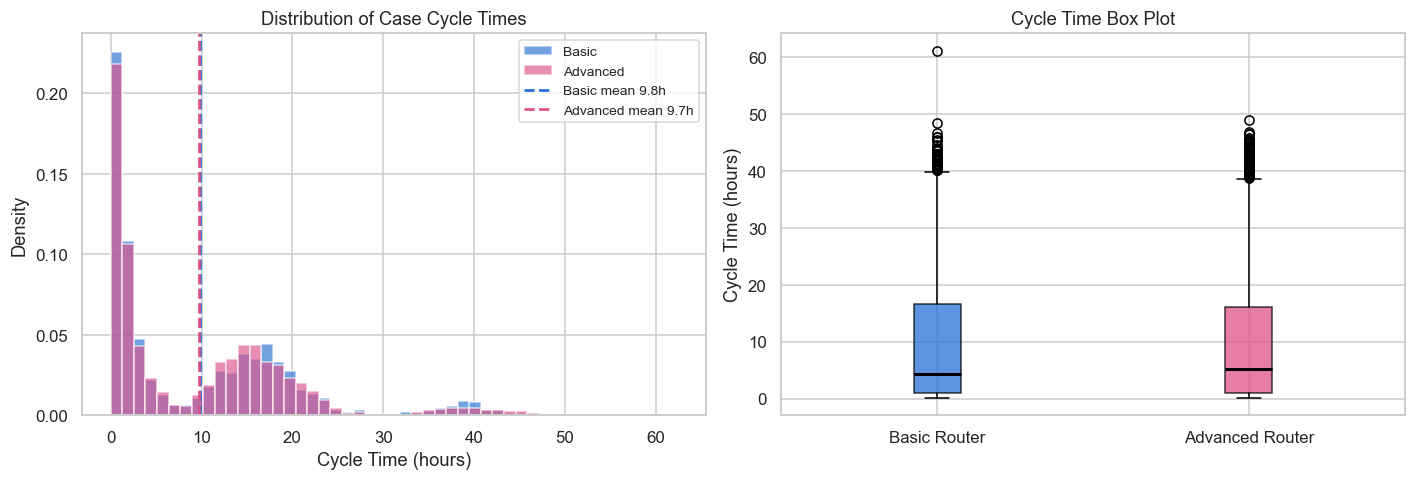

Saved -> results/metric1_cycle_time.png


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: histogram
ax = axes[0]
bins = np.linspace(0, max(basic_ct.max(), advanced_ct.max()) * 1.02, 50)
ax.hist(basic_ct,    bins=bins, alpha=0.65, color=COLORS['basic'],    label='Basic',    density=True)
ax.hist(advanced_ct, bins=bins, alpha=0.65, color=COLORS['advanced'], label='Advanced', density=True)
ax.axvline(basic_ct.mean(),    color=COLORS['basic'],    linestyle='--', lw=1.8,
           label=f'Basic mean {basic_ct.mean():.1f}h')
ax.axvline(advanced_ct.mean(), color=COLORS['advanced'], linestyle='--', lw=1.8,
           label=f'Advanced mean {advanced_ct.mean():.1f}h')
ax.set_xlabel('Cycle Time (hours)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Case Cycle Times')
ax.legend(fontsize=9)

# Right: boxplot
ax2 = axes[1]
data = [basic_ct.values, advanced_ct.values]
bp = ax2.boxplot(data, patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], [COLORS['basic'], COLORS['advanced']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['Basic Router', 'Advanced Router'])
ax2.set_ylabel('Cycle Time (hours)')
ax2.set_title('Cycle Time Box Plot')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric1_cycle_time.png', bbox_inches='tight')
plt.show()
print('Saved -> results/metric1_cycle_time.png')

## Metric 2 – Average Resource Occupation

**Definition:** For each resource $r$, occupation is the fraction of scheduled working time actually spent executing tasks:
$$\text{occ}(r) = \frac{\sum_{e\,:\,\text{resource}=r} (t^{\text{complete}}_e - t^{\text{start}}_e)}{\text{AvailableTime}(r)}$$

The **Average Resource Occupation** is the mean over all resources:  
$$\overline{\text{occ}} = \frac{1}{|\mathcal{R}|}\sum_{r \in \mathcal{R}} \text{occ}(r)$$

> **Note:** Only *Workflow* activities (`W_*`) have explicit `start` / `complete` event pairs in this simulator; Application (`A_*`) and Offer (`O_*`) events are instantaneous and do not contribute to working time.

In [36]:
# Compute working time per resource
print('Computing working time per resource...')
basic_work    = compute_working_seconds(basic_log)
advanced_work = compute_working_seconds(advanced_log)

# Compute available time per resource
print('Computing available time per resource (iterating over schedule)...')
available = compute_available_seconds(avail_df)

# Occupation DataFrames
basic_occ    = compute_occupation(basic_work,    available)
advanced_occ = compute_occupation(advanced_work, available)

# Summary
occ_summary = pd.DataFrame({
    'Mean Occupation':   [basic_occ['occupation'].mean(),   advanced_occ['occupation'].mean()],
    'Median Occupation': [basic_occ['occupation'].median(), advanced_occ['occupation'].median()],
    'Std':               [basic_occ['occupation'].std(),    advanced_occ['occupation'].std()],
    'Max':               [basic_occ['occupation'].max(),    advanced_occ['occupation'].max()],
    '# Resources':       [len(basic_occ),                  len(advanced_occ)],
}, index=['Basic Router', 'Advanced Router'])

print('\nMETRIC 2: AVERAGE RESOURCE OCCUPATION')
print((occ_summary * [100, 100, 100, 100, 1]).round(2).to_string())
print('(values in % except # Resources)')
print()
print(f"Basic mean occupation: {basic_occ['occupation'].mean()*100:.3f}%")
print(f"Advanced mean occupation: {advanced_occ['occupation'].mean()*100:.3f}%")

Computing working time per resource...
Computing available time per resource (iterating over schedule)...

METRIC 2: AVERAGE RESOURCE OCCUPATION
                 Mean Occupation  Median Occupation    Std    Max  # Resources
Basic Router               21.23               5.02  32.97  100.0          140
Advanced Router            21.82               4.34  33.80  100.0          140
(values in % except # Resources)

Basic mean occupation: 21.233%
Advanced mean occupation: 21.823%


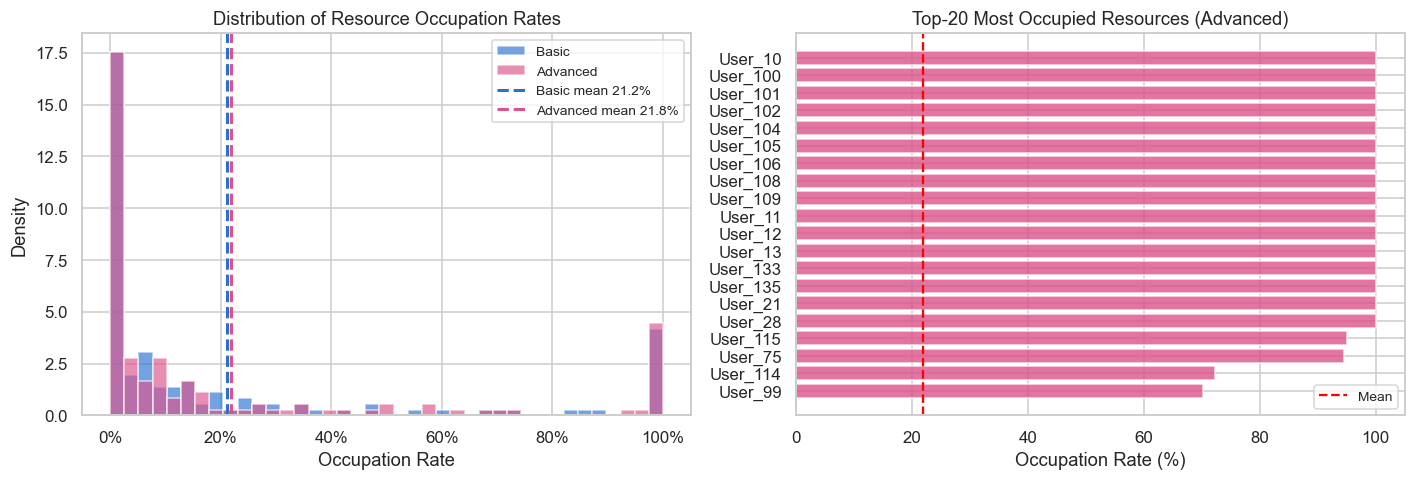

Saved -> results/metric2_resource_occupation.png


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: distribution of occupation rates
ax = axes[0]
bins = np.linspace(0, 1, 40)
ax.hist(basic_occ['occupation'],    bins=bins, alpha=0.65, color=COLORS['basic'],    label='Basic',    density=True)
ax.hist(advanced_occ['occupation'], bins=bins, alpha=0.65, color=COLORS['advanced'], label='Advanced', density=True)
ax.axvline(basic_occ['occupation'].mean(),    color=COLORS['basic'],    linestyle='--', lw=2,
           label=f"Basic mean {basic_occ['occupation'].mean()*100:.1f}%")
ax.axvline(advanced_occ['occupation'].mean(), color=COLORS['advanced'], linestyle='--', lw=2,
           label=f"Advanced mean {advanced_occ['occupation'].mean()*100:.1f}%")
ax.set_xlabel('Occupation Rate')
ax.set_ylabel('Density')
ax.set_title('Distribution of Resource Occupation Rates')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=9)

# Right: top-20 most occupied resources (advanced)
ax2 = axes[1]
top20 = advanced_occ.nlargest(20, 'occupation')
ax2.barh(top20.index[::-1], top20['occupation'][::-1] * 100,
         color=COLORS['advanced'], alpha=0.8)
ax2.axvline(advanced_occ['occupation'].mean() * 100,
            color='red', linestyle='--', lw=1.5, label='Mean')
ax2.set_xlabel('Occupation Rate (%)')
ax2.set_title('Top-20 Most Occupied Resources (Advanced)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric2_resource_occupation.png', bbox_inches='tight')
plt.show()
print('Saved -> results/metric2_resource_occupation.png')

## Metric 3 – (Weighted) Resource Fairness

**Definition:** Fairness measures how evenly the workload is spread across resources. We use the **Mean Absolute Deviation (MAD)** from the average occupation:

$$\text{Fairness}_{\text{unweighted}} = \frac{1}{|\mathcal{R}|}\sum_{r}|\text{occ}(r) - \overline{\text{occ}}|$$

**Weighted variant** — resources with longer availability periods count more:

$$\text{Fairness}_{\text{weighted}} = \sum_{r} w_r \cdot |\text{occ}(r) - \overline{\text{occ}}|, \quad w_r = \frac{\text{AvailableTime}(r)}{\sum_{r'}\text{AvailableTime}(r')}$$

**Lower = fairer** (smaller deviation = more equal load distribution).

In [38]:
# Compute fairness
b_mean, b_mad, b_wmad = fairness_metrics(
    basic_occ['occupation'], basic_occ['available_seconds'])
a_mean, a_mad, a_wmad = fairness_metrics(
    advanced_occ['occupation'], advanced_occ['available_seconds'])

# Active-resources-only fairness (task_count > 0)
def _active_occ(occ_frame, log):
    task_cnt = (
        log[log['lifecycle:transition'] == 'start']
        .groupby('org:resource').size()
    )
    return occ_frame[occ_frame.index.isin(task_cnt[task_cnt > 0].index)]

b_occ_active = _active_occ(basic_occ,    basic_log)
a_occ_active = _active_occ(advanced_occ, advanced_log)
_, b_mad_act, b_wmad_act = fairness_metrics(b_occ_active['occupation'], b_occ_active['available_seconds'])
_, a_mad_act, a_wmad_act = fairness_metrics(a_occ_active['occupation'], a_occ_active['available_seconds'])

fairness_summary = pd.DataFrame({
    'Mean Occupation':                [b_mean,      a_mean],
    'MAD (unweighted, all)':          [b_mad,       a_mad],
    'MAD (weighted, all)':            [b_wmad,      a_wmad],
    'MAD (unweighted, active only)':  [b_mad_act,   a_mad_act],
    'MAD (weighted, active only)':    [b_wmad_act,  a_wmad_act],
    'Fairness Score (1-MAD, all)':    [1-b_mad,     1-a_mad],
}, index=['Basic Router', 'Advanced Router'])

print('METRIC 3: RESOURCE FAIRNESS')
print(fairness_summary.round(5).to_string())
print()
print('Interpretation: Lower MAD = fairer workload distribution')
print(f"  Basic   – all: {b_mad:.5f} / {b_wmad:.5f}  |  active only: {b_mad_act:.5f} / {b_wmad_act:.5f}")
print(f"  Advanced – all: {a_mad:.5f} / {a_wmad:.5f}  |  active only: {a_mad_act:.5f} / {a_wmad_act:.5f}")
print(f"  (Active-only excludes {len(basic_occ) - len(b_occ_active)} basic / {len(advanced_occ) - len(a_occ_active)} advanced resources with zero tasks)")

METRIC 3: RESOURCE FAIRNESS
                 Mean Occupation  MAD (unweighted, all)  MAD (weighted, all)  MAD (unweighted, active only)  MAD (weighted, active only)  Fairness Score (1-MAD, all)
Basic Router             0.21233                0.25004              0.25253                        0.27712                      0.27848                      0.74996
Advanced Router          0.21823                0.26216              0.26629                        0.29105                      0.29460                      0.73784

Interpretation: Lower MAD = fairer workload distribution
  Basic   – all: 0.25004 / 0.25253  |  active only: 0.27712 / 0.27848
  Advanced – all: 0.26216 / 0.26629  |  active only: 0.29105 / 0.29460
  (Active-only excludes 26 basic / 26 advanced resources with zero tasks)


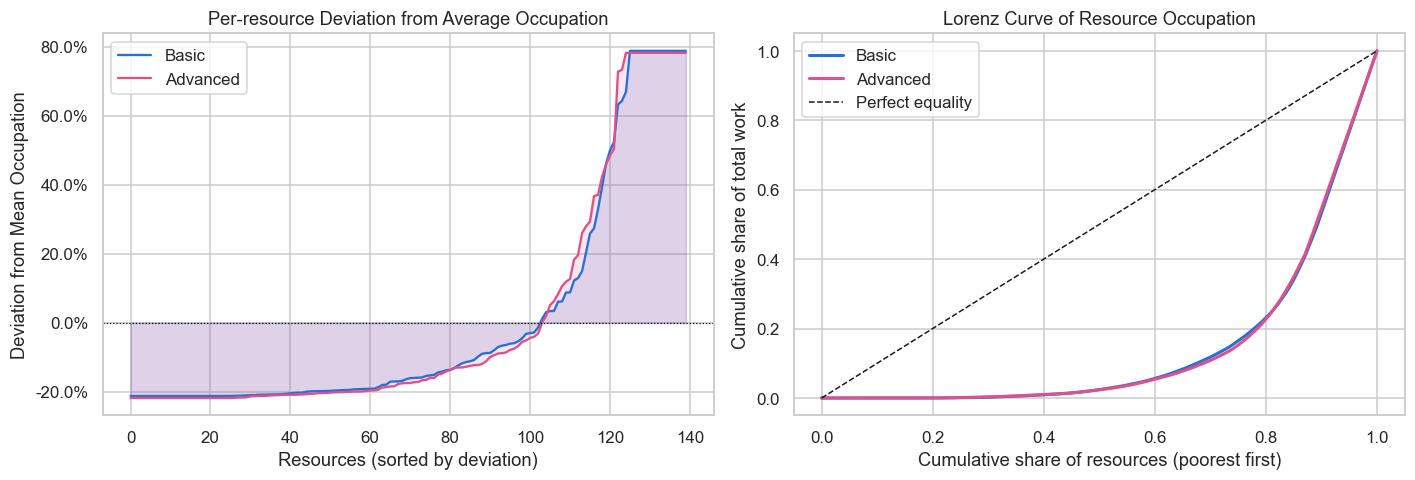

Saved -> results/metric3_resource_fairness.png


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: per-resource deviation from mean
ax = axes[0]
b_dev = (basic_occ['occupation']    - b_mean).sort_values()
a_dev = (advanced_occ['occupation'] - a_mean).sort_values()

ax.plot(range(len(b_dev)), b_dev.values,    color=COLORS['basic'],    lw=1.5, label='Basic')
ax.plot(range(len(a_dev)), a_dev.values,    color=COLORS['advanced'], lw=1.5, label='Advanced')
ax.axhline(0, color='black', lw=0.8, linestyle=':')
ax.fill_between(range(len(b_dev)), b_dev.values, 0,
                where=(b_dev.values > 0), alpha=0.15, color=COLORS['basic'])
ax.fill_between(range(len(b_dev)), b_dev.values, 0,
                where=(b_dev.values < 0), alpha=0.15, color=COLORS['basic'])
ax.fill_between(range(len(a_dev)), a_dev.values, 0,
                where=(a_dev.values > 0), alpha=0.15, color=COLORS['advanced'])
ax.fill_between(range(len(a_dev)), a_dev.values, 0,
                where=(a_dev.values < 0), alpha=0.15, color=COLORS['advanced'])
ax.set_xlabel('Resources (sorted by deviation)')
ax.set_ylabel('Deviation from Mean Occupation')
ax.set_title('Per-resource Deviation from Average Occupation')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
ax.legend()

# Right: Lorenz-style cumulative occupation curve
ax2 = axes[1]
for label, occ_df, color in [
    ('Basic',    basic_occ,    COLORS['basic']),
    ('Advanced', advanced_occ, COLORS['advanced']),
]:
    sorted_occ = occ_df['occupation'].sort_values().values
    cum = np.cumsum(sorted_occ) / sorted_occ.sum()
    x = np.linspace(0, 1, len(cum))
    ax2.plot(x, cum, color=color, lw=2, label=label)
ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect equality')
ax2.set_xlabel('Cumulative share of resources (poorest first)')
ax2.set_ylabel('Cumulative share of total work')
ax2.set_title('Lorenz Curve of Resource Occupation')
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric3_resource_fairness.png', bbox_inches='tight')
plt.show()
print('Saved -> results/metric3_resource_fairness.png')

## Summary Dashboard – Basic vs Advanced Router

Consolidating all three metrics to directly compare routing strategies.

In [41]:
summary = pd.DataFrame({
    'Metric': [
        'Avg Cycle Time (h)',
        'Avg Cycle Time (days)',
        'Avg Resource Occupation (%)',
        'Fairness – MAD (unweighted)',
        'Fairness – MAD (weighted)',
        #'Outcome Fidelity (1 − JSD)',
    ],
    'Basic Router': [
        round(basic_ct.mean(), 2),
        round(basic_ct.mean() / 24, 3),
        round(basic_occ['occupation'].mean() * 100, 3),
        round(b_mad, 5),
        round(b_wmad, 5),
        #round(fidelity_b, 4),
    ],
    'Advanced Router': [
        round(advanced_ct.mean(), 2),
        round(advanced_ct.mean() / 24, 3),
        round(advanced_occ['occupation'].mean() * 100, 3),
        round(a_mad, 5),
        round(a_wmad, 5),
        #round(fidelity_a, 4),
    ],
})
summary['Better'] = summary.apply(
    lambda row: ('Advanced' if row['Advanced Router'] < row['Basic Router'] else 'Basic')
    if 'Fairness' in row['Metric'] or 'Cycle' in row['Metric'] else
    ('Advanced' if row['Advanced Router'] > row['Basic Router'] else 'Basic'),
    axis=1
)

print('         EVALUATION SUMMARY – ALL FOUR METRICS')
print(summary.to_string(index=False))
print()
print('Note: Cycle Time and Fairness MAD  → lower is better.')
print('      Resource Occupation          → higher is better.')
print('      Outcome Fidelity (1 − JSD)   → higher is better.')

         EVALUATION SUMMARY – ALL FOUR METRICS
                     Metric  Basic Router  Advanced Router   Better
         Avg Cycle Time (h)       9.83000          9.71000 Advanced
      Avg Cycle Time (days)       0.41000          0.40500 Advanced
Avg Resource Occupation (%)      21.23300         21.82300 Advanced
Fairness – MAD (unweighted)       0.25004          0.26216    Basic
  Fairness – MAD (weighted)       0.25253          0.26629    Basic

Note: Cycle Time and Fairness MAD  → lower is better.
      Resource Occupation          → higher is better.
      Outcome Fidelity (1 − JSD)   → higher is better.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

labels = ['Basic', 'Advanced']

# Cycle Time
ax = axes[0]
vals = [basic_ct.mean(), advanced_ct.mean()]
bars = ax.bar(labels, vals, color=[COLORS['basic'], COLORS['advanced']], alpha=0.8, width=0.5)
ax.bar_label(bars, fmt='%.1f h', padding=3, fontsize=10)
ax.set_ylabel('Hours')
ax.set_title('Avg Cycle Time\n(lower = faster)')
ax.set_ylim(0, max(vals) * 1.2)

# Resource Occupation
ax2 = axes[1]
vals2 = [basic_occ['occupation'].mean() * 100, advanced_occ['occupation'].mean() * 100]
bars2 = ax2.bar(labels, vals2, color=[COLORS['basic'], COLORS['advanced']], alpha=0.8, width=0.5)
ax2.bar_label(bars2, fmt='%.2f%%', padding=3, fontsize=10)
ax2.set_ylabel('Occupation Rate (%)')
ax2.set_title('Avg Resource Occupation\n(higher = more productive)')
ax2.set_ylim(0, max(vals2) * 1.3)

# Fairness (unweighted MAD)
ax3 = axes[2]
vals3 = [b_mad, a_mad]
bars3 = ax3.bar(labels, vals3, color=[COLORS['basic'], COLORS['advanced']], alpha=0.8, width=0.5)
ax3.bar_label(bars3, fmt='%.4f', padding=3, fontsize=10)
ax3.set_ylabel('MAD')
ax3.set_title('Resource Fairness (MAD)\n(lower = fairer)')
ax3.set_ylim(0, max(vals3) * 1.3)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Evaluation Summary: Basic vs Advanced Router', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'summary_dashboard.png', bbox_inches='tight')
plt.show()
print('Saved -> results/summary_dashboard.png')

## Simulation Validation – Real Log vs Simulated Logs

Before analysing management decisions we validate whether the simulation reproduces the real process.  
We compare the **Advanced Router** (best-performing sim) against the **BPI 2017 real event log** (full log, 31,509 cases).

> **Scope note:** The full real log is used without period filtering. Filtering to cases that start and complete within the 18-day simulation window would retain only the fastest ~1% of real cases, introducing severe selection bias. Absolute cycle time values are not expected to match due to simulation time compression; distribution shape and compression ratio are the meaningful comparison points.

In [ ]:
import pm4py

# Load full real log — no period filtering for cycle time.
# Cycle time is a per-case metric; filtering to cases that complete within
# the sim window introduces severe selection bias (only the fastest ~1% of cases).
# Using the full log gives an unbiased cycle time distribution.
real_raw = pm4py.read_xes(str(BASE / 'data/BPI Challenge 2017.xes.gz'))
real_df  = pm4py.convert_to_dataframe(real_raw)
real_df['time:timestamp'] = pd.to_datetime(real_df['time:timestamp'], utc=True).dt.tz_localize(None)

real_log = real_df.copy()
real_ct  = compute_cycle_times(real_log)

n_real_cases = real_log['case:concept:name'].nunique()
print(f"Real log — total cases : {n_real_cases:,}")
print(f"Real log — total events: {len(real_log):,}")
print()
print(f"Avg CT real (full log) : {real_ct.mean():.2f} h  ({real_ct.mean()/24:.1f} days)")
print(f"Avg CT advanced sim    : {advanced_ct.mean():.2f} h  ({advanced_ct.mean()/24:.2f} days)")
print(f"Compression ratio      : {real_ct.mean()/advanced_ct.mean():.0f}×")

In [ ]:
REAL_COLOR = '#2ECC71'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Cycle Time distributions
ax = axes[0]
clip_h = 2000
for label, ct_series, color in [
    (f'Real (n={len(real_ct):,})',     real_ct,     REAL_COLOR),
    (f'Basic (n={len(basic_ct):,})',   basic_ct,    COLORS['basic']),
    (f'Advanced (n={len(advanced_ct):,})', advanced_ct, COLORS['advanced']),
]:
    ax.hist(ct_series.clip(upper=clip_h), bins=60, alpha=0.55,
            color=color, label=f'{label} (mean {ct_series.mean():.0f} h)', density=True)
    ax.axvline(min(ct_series.mean(), clip_h), color=color, linestyle='--', lw=1.8)

ax.set_xlabel(f'Cycle Time (hours, clipped at {clip_h} h)')
ax.set_ylabel('Density')
ax.set_title('Cycle Time Distribution\nReal (full log) vs Simulated')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2: Activity share comparison (complete events only, completed cases)
# W_ activities in the real log each generate many extra lifecycle events
# (schedule, start, suspend, resume, ate_abort, complete) that the simulation
# does not model — only start+complete are logged in the simulation.
# We normalise both sides to complete lifecycle events for a fair comparison.

real_complete = real_log[real_log['lifecycle:transition'].str.lower() == 'complete'].copy() \
    if 'lifecycle:transition' in real_log.columns else real_log.copy()

adv_case_len   = advanced_log.groupby('case:concept:name').size()
basic_case_len = basic_log.groupby('case:concept:name').size()
adv_completed  = advanced_log[
    advanced_log['case:concept:name'].isin(adv_case_len[adv_case_len > 2].index) &
    (advanced_log['lifecycle:transition'] == 'complete')
]
basic_completed = basic_log[
    basic_log['case:concept:name'].isin(basic_case_len[basic_case_len > 2].index) &
    (basic_log['lifecycle:transition'] == 'complete')
]

n_adv_comp   = adv_case_len[adv_case_len > 2].shape[0]
n_basic_comp = basic_case_len[basic_case_len > 2].shape[0]
print(f"Completed cases used for activity distribution:")
print(f"  Advanced: {n_adv_comp} / {len(adv_case_len)} ({n_adv_comp/len(adv_case_len)*100:.1f}%)")
print(f"  Basic   : {n_basic_comp} / {len(basic_case_len)} ({n_basic_comp/len(basic_case_len)*100:.1f}%)")
print(f"  Real COMPLETE events: {len(real_complete):,} (from {real_log['case:concept:name'].nunique():,} cases)")

ax2 = axes[1]
top_acts = (real_complete['concept:name'].value_counts(normalize=True) * 100).head(10).index.tolist()

real_shares  = real_complete['concept:name'].value_counts(normalize=True) * 100
basic_shares = basic_completed['concept:name'].value_counts(normalize=True) * 100
adv_shares   = adv_completed['concept:name'].value_counts(normalize=True) * 100

x = np.arange(len(top_acts))
w = 0.26
ax2.barh(x + w,   [real_shares.get(a, 0)  for a in top_acts], w, color=REAL_COLOR,        alpha=0.8, label=f'Real full log ({real_log["case:concept:name"].nunique():,} cases)')
ax2.barh(x,       [adv_shares.get(a, 0)   for a in top_acts], w, color=COLORS['advanced'], alpha=0.8, label=f'Advanced ({n_adv_comp} cases)')
ax2.barh(x - w,   [basic_shares.get(a, 0) for a in top_acts], w, color=COLORS['basic'],    alpha=0.8, label=f'Basic ({n_basic_comp} cases)')

ax2.set_yticks(x)
ax2.set_yticklabels(top_acts, fontsize=9)
ax2.set_xlabel('Share of all complete events (%)')
ax2.set_title('Activity Distribution\n(complete events only — lifecycle-normalised)')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.suptitle('Simulation Validation: Real vs Simulated Logs', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'validation_real_vs_sim.png', bbox_inches='tight')
plt.show()
print('Saved -> results/validation_real_vs_sim.png')

### Validation – Metric 1: Cycle Time vs Real Log

> **Methodological note:** The simulation compresses external waiting times (inter-arrival queuing, manual review delays, overnight gaps) that are present in the real process but not modelled. This means cycle times will never match numerically — the gap is structural, not a simulation error.  
> The **full real log** (31,509 cases) is used to avoid selection bias: filtering to only cases that complete within the 18-day sim window would retain only the fastest ~1% of real cases, making the comparison misleading. Distribution shape and compression ratio are the meaningful indicators here.

In [ ]:
n_real_ct = len(real_ct)
n_adv_ct  = len(advanced_ct)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: overlapping histograms (clip real log for readability)
ax = axes[0]
clip_h = 2000
ax.hist(real_ct.clip(upper=clip_h), bins=60, alpha=0.65, color=REAL_COLOR,
        density=True, label=f'Real (mean {real_ct.mean():.0f} h, clipped at {clip_h} h, n={n_real_ct:,})')
ax.hist(advanced_ct, bins=40, alpha=0.65, color=COLORS['advanced'],
        density=True, label=f'Advanced sim (mean {advanced_ct.mean():.1f} h, n={n_adv_ct:,})')
ax.axvline(min(real_ct.mean(), clip_h), color=REAL_COLOR,         linestyle='--', lw=1.8)
ax.axvline(advanced_ct.mean(),          color=COLORS['advanced'], linestyle='--', lw=1.8)
ax.set_xlabel('Cycle Time (hours)')
ax.set_ylabel('Density')
ax.set_title('Cycle Time Distribution\nReal (full log) vs Advanced Sim')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: mean / median bar comparison
ax2 = axes[1]
labels_ct = [f'Real log\n(n={n_real_ct:,})', f'Advanced sim\n(n={n_adv_ct:,})']
means   = [real_ct.mean(),   advanced_ct.mean()]
medians = [real_ct.median(), advanced_ct.median()]
x = np.arange(2)
w = 0.35
bars_m  = ax2.bar(x - w/2, means,   w, color=[REAL_COLOR, COLORS['advanced']], alpha=0.85, label='Mean')
bars_md = ax2.bar(x + w/2, medians, w, color=[REAL_COLOR, COLORS['advanced']], alpha=0.45, label='Median', edgecolor='grey')
ax2.bar_label(bars_m,  fmt='%.1f h', padding=3, fontsize=9)
ax2.bar_label(bars_md, fmt='%.1f h', padding=3, fontsize=9)
ax2.set_xticks(x)
ax2.set_xticklabels(labels_ct, fontsize=9)
ax2.set_ylabel('Hours')
ax2.set_title('Mean & Median Cycle Time\n(note: y-axis scale difference)')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'validation_cycle_time.png', bbox_inches='tight')
plt.show()
print(f"Real log mean CT  : {real_ct.mean():.2f} h  ({real_ct.mean()/24:.1f} days)")
print(f"Advanced sim mean : {advanced_ct.mean():.2f} h  ({advanced_ct.mean()/24:.2f} days)")
print(f"Compression ratio : {real_ct.mean()/advanced_ct.mean():.0f}×")
print('Saved -> results/validation_cycle_time.png')

### Validation – Metrics 2 & 3: Resource Occupation & Fairness vs Real Log

> **Methodological note:** For resource metrics, filtering by case completion would bias toward fast cases. Instead we use **all W_ `start`/`complete` event pairs whose timestamps fall within the simulation period** (2016-05-17 → 2016-06-04), regardless of whether the case started or finished in the window. This gives an unbiased picture of what resources were actually doing during the same 18 days.
>
> The same resource availability schedule is used for both real log and simulation.

In [ ]:
SIM_START_DT = pd.Timestamp('2016-05-17')
SIM_END_DT   = pd.Timestamp('2016-06-05')  # exclusive upper bound

# Filter real_df to W_ activities within the sim period
real_w = real_df[
    real_df['concept:name'].isin(W_ACTIVITIES) &
    (real_df['time:timestamp'] >= SIM_START_DT) &
    (real_df['time:timestamp'] <  SIM_END_DT)
].copy()

# Determine lifecycle column (the real log uses 'lifecycle:transition')
lc_col = 'lifecycle:transition'
if lc_col not in real_w.columns:
    lc_col = None

if lc_col:
    real_w_starts    = real_w[real_w[lc_col].str.lower() == 'start']
    real_w_completes = real_w[real_w[lc_col].str.lower() == 'complete']
else:
    # Fallback: first and last event per (case, activity, resource)
    real_w_starts    = real_w
    real_w_completes = real_w

# Build start/complete pairs using case + activity + resource key
r_starts = (real_w_starts[['case:concept:name','concept:name','org:resource','time:timestamp']]
            .rename(columns={'time:timestamp':'start_time'}))
r_completes = (real_w_completes[['case:concept:name','concept:name','org:resource','time:timestamp']]
               .rename(columns={'time:timestamp':'end_time'}))

real_pairs = pd.merge(r_starts, r_completes,
                      on=['case:concept:name','concept:name','org:resource'])
real_pairs['working_seconds'] = (
    (real_pairs['end_time'] - real_pairs['start_time'])
    .dt.total_seconds()
    .clip(lower=0)
)

real_work_period = real_pairs.groupby('org:resource')['working_seconds'].sum()

print(f"Real log W_ events in period : {len(real_w):,}")
print(f"  start events : {len(real_w_starts):,}")
print(f"  complete events: {len(real_w_completes):,}")
print(f"  matched pairs: {len(real_pairs):,}")
print(f"  active resources: {real_work_period.shape[0]}")

real_occ_period = compute_occupation(real_work_period, available)
r_mean, r_mad, r_wmad = fairness_metrics(
    real_occ_period['occupation'], real_occ_period['available_seconds'])

print(f"\nMETRIC 2 & 3 COMPARISON (Real log period events vs Advanced sim)")
comp_df_res = pd.DataFrame({
    'Mean Occupation (%)': [r_mean*100, advanced_occ['occupation'].mean()*100],
    'Median Occupation (%)': [real_occ_period['occupation'].median()*100,
                              advanced_occ['occupation'].median()*100],
    'MAD (unweighted)': [r_mad, a_mad],
    'MAD (weighted)':   [r_wmad, a_wmad],
    'Fairness Score (1-MAD)': [1-r_mad, 1-a_mad],
    '# Active Resources': [len(real_occ_period), len(advanced_occ)],
}, index=['Real log (period)', 'Advanced sim'])
print(comp_df_res.round(4).to_string())

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

labels_rv = ['Real log\n(period)', 'Advanced sim']
colors_rv  = [REAL_COLOR, COLORS['advanced']]

# Panel 1: Mean occupation
ax = axes[0]
vals_occ = [r_mean * 100, advanced_occ['occupation'].mean() * 100]
bars = ax.bar(labels_rv, vals_occ, color=colors_rv, alpha=0.85, width=0.45)
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=10)
ax.set_ylabel('Occupation Rate (%)')
ax.set_title('Avg Resource Occupation\n(higher = more productive)')
ax.set_ylim(0, max(vals_occ) * 1.35)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2: Fairness MAD
ax2 = axes[1]
vals_mad = [r_mad, a_mad]
bars2 = ax2.bar(labels_rv, vals_mad, color=colors_rv, alpha=0.85, width=0.45)
ax2.bar_label(bars2, fmt='%.4f', padding=3, fontsize=10)
ax2.set_ylabel('MAD (unweighted)')
ax2.set_title('Resource Fairness (MAD)\n(lower = fairer)')
ax2.set_ylim(0, max(vals_mad) * 1.35)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# Panel 3: Occupation distribution
ax3 = axes[2]
bins = np.linspace(0, 1, 35)
ax3.hist(real_occ_period['occupation'], bins=bins, alpha=0.65, color=REAL_COLOR,
         density=True, label=f'Real (n={len(real_occ_period)} res.)')
ax3.hist(advanced_occ['occupation'], bins=bins, alpha=0.65, color=COLORS['advanced'],
         density=True, label=f'Advanced sim (n={len(advanced_occ)} res.)')
ax3.axvline(r_mean, color=REAL_COLOR,         linestyle='--', lw=1.8)
ax3.axvline(a_mean, color=COLORS['advanced'], linestyle='--', lw=1.8)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax3.set_xlabel('Occupation Rate')
ax3.set_ylabel('Density')
ax3.set_title('Distribution of Occupation Rates\nReal vs Advanced sim')
ax3.legend(fontsize=9)
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

plt.suptitle('Metrics 2 & 3 – Resource Occupation & Fairness: Real vs Advanced Sim',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'validation_resource_metrics.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved -> results/validation_resource_metrics.png')

### Simulation Configuration

Both simulated logs evaluated in this notebook were produced with the **same fixed infrastructure settings**, varying only the decision routing strategy:

| Component | Setting | Rationale |
|---|---|---|
| **Resource Allocator** | `SHORTEST_QUEUE` | Assigns each task to the permitted resource with the shortest current queue length |
| **Processing Time Model** | QR (`pt_use_qr=True`) | Lower pinball loss than parametric baseline |
| **Availability Schedule** | `availabilities_advanced.csv` | Full realistic shift coverage |
| **Decision Routing – Basic** | `DPManager(mode="basic")` | Probability-based routing from real log |
| **Decision Routing – Advanced** | `DPManager(mode="advanced")` | C4.5 tree trained on real log |
| **Simulation window** | 2016-05-17 → 2016-06-04 | 18 days, ~100 000 events, ~2 000 cases |

The decision routing strategy is the **only independent variable** in this evaluation. Resource allocation and processing times are held constant to isolate the effect of the routing model.

In [ ]:
results_rows = []
for router, ct_series, occ_frame, mad_val, wmad_val in [
    ('Basic',    basic_ct,    basic_occ,    b_mad, b_wmad),
    ('Advanced', advanced_ct, advanced_occ, a_mad, a_wmad),
]:
    results_rows.append({
        'Router':                    router,
        'Avg Cycle Time (h)':        round(ct_series.mean(), 4),
        'Median Cycle Time (h)':     round(ct_series.median(), 4),
        'Avg Resource Occupation':   round(occ_frame['occupation'].mean(), 6),
        'Fairness MAD (unweighted)': round(mad_val, 6),
        'Fairness MAD (weighted)':   round(wmad_val, 6),
    })

results_df = pd.DataFrame(results_rows)
results_df.to_csv(RESULTS_DIR / 'evaluation_metrics.csv', index=False)
print('Saved results/evaluation_metrics.csv')
print(results_df.to_string(index=False))

## Metric 4 – Outcome Distribution Fidelity

**Definition:** Each case is classified into one of six outcome categories based on which terminal activities appear in its trace. Priority order reflects the three process paths in BPI 2017:

| Process Path | Terminal activity | Outcome label |
|---|---|---|
| Initiating Process | `A_Complete` | **Complete** |
| Initiating Process (partial) | `A_Accepted` or `O_Accepted` | **Accepted** |
| Pending Process | `A_Denied` | **Denied** |
| Pending Process | `O_Refused` | **Refused** |
| Not Pending / Pending | `A_Cancelled` or `O_Cancelled` | **Cancelled** |
| Pending Process | `A_Pending` | **Pending** |
| — | none of the above | **Other** |

The fidelity score:

$$\text{Outcome Fidelity} = 1 - \text{JSD}(P_{\text{real}},\, P_{\text{sim}})$$

**Higher fidelity (lower JSD)** → routing decisions lead to realistic process outcomes. Reference is the real log **filtered to terminal cases only** (cases whose last activity is a known outcome activity), excluding right-censored cases still in-flight at observation cutoff.

In [ ]:
# Last activity distribution — real log (all cases) vs Basic vs Advanced
# Real log includes right-censored cases (workflow activities as last event)
# which reveals how many cases were still in-flight when the log was cut off.

def last_activity_dist(df):
    last = (
        df.sort_values('time:timestamp')
          .groupby('case:concept:name')['concept:name']
          .last()
    )
    return last.value_counts(normalize=True) * 100

# Filter real log to complete lifecycle events
real_complete = real_log[real_log['lifecycle:transition'].str.lower() == 'complete'].copy() \
    if 'lifecycle:transition' in real_log.columns else real_log.copy()

real_last  = last_activity_dist(real_complete)
basic_last = last_activity_dist(basic_log)
adv_last   = last_activity_dist(advanced_log)

n_real  = real_complete['case:concept:name'].nunique()
n_basic = basic_log['case:concept:name'].nunique()
n_adv   = advanced_log['case:concept:name'].nunique()

# All activities sorted by real log frequency
all_last_acts = sorted(
    set(real_last.index) | set(basic_last.index) | set(adv_last.index),
    key=lambda a: -real_last.get(a, 0)
)

df_last = pd.DataFrame({
    'Activity':  all_last_acts,
    'Real (%)':  [real_last.get(a, 0)  for a in all_last_acts],
    'Basic (%)': [basic_last.get(a, 0) for a in all_last_acts],
    'Adv (%)':   [adv_last.get(a, 0)   for a in all_last_acts],
})
print(f"Last activity distribution  (Real n={n_real:,} | Basic n={n_basic:,} | Advanced n={n_adv:,})")
print(df_last.round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(all_last_acts))
w = 0.26
ax.bar(x - w, [real_last.get(a, 0)  for a in all_last_acts], w,
       label=f'Real (n={n_real:,})', color=REAL_COLOR, alpha=0.85)
ax.bar(x,     [basic_last.get(a, 0) for a in all_last_acts], w,
       label=f'Basic (n={n_basic:,})', color=COLORS['basic'], alpha=0.85)
ax.bar(x + w, [adv_last.get(a, 0)   for a in all_last_acts], w,
       label=f'Advanced (n={n_adv:,})', color=COLORS['advanced'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(all_last_acts, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Share of cases (%)')
ax.set_title('Last Activity Distribution per Case\nReal vs Basic vs Advanced')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout(pad=2.0)
plt.savefig(RESULTS_DIR / 'metric4_last_activity_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> results/metric4_last_activity_dist.png')

In [ ]:
from scipy.spatial.distance import jensenshannon

# Fixed outcome categories
OUTCOME_CATEGORIES = ['Cancelled', 'Pending', 'Refused', 'Complete', 'Accepted', 'Denied', 'Other']

OUTCOME_COLORS = {
    'Cancelled': '#E74C3C',
    'Pending':   "#ED9D1D",
    'Refused':   "#8B32B1",
    'Complete':  "#37F285",
    'Accepted':  "#09A048",
    'Denied':    "#901508",
    'Other':     "#B5B8BA",
}

_LAST_ACT_OUTCOME = {
    'A_Complete':  'Complete',
    'A_Accepted':  'Accepted',
    'O_Accepted':  'Accepted',
    'A_Denied':    'Denied',
    'O_Refused':   'Refused',
    'A_Cancelled': 'Cancelled',
    'O_Cancelled': 'Cancelled',
    'A_Pending':   'Pending',
}
TERMINAL_ACTS = set(_LAST_ACT_OUTCOME.keys())

def classify_outcomes(df, terminal_filter=True):
    last = (
        df.sort_values('time:timestamp')
          .groupby('case:concept:name')['concept:name']
          .last()
    )
    if terminal_filter:
        last = last[last.isin(TERMINAL_ACTS)]
    return last.map(lambda a: _LAST_ACT_OUTCOME.get(a, 'Other'))

def outcome_dist(outcome_series):
    counts = outcome_series.value_counts()
    total = counts.sum()
    return {cat: counts.get(cat, 0) / total for cat in OUTCOME_CATEGORIES}

def jsd_outcomes(p, q):
    pv = np.array([p[k] for k in OUTCOME_CATEGORIES], dtype=float)
    qv = np.array([q[k] for k in OUTCOME_CATEGORIES], dtype=float)
    if pv.sum() > 0: pv /= pv.sum()
    if qv.sum() > 0: qv /= qv.sum()
    return float(jensenshannon(pv, qv))

# Apply terminal_filter=True to all three: only cases that reached a
# definitive outcome are included, removing right-censored/incomplete cases
# consistently across real log and simulated logs.
real_outcomes  = classify_outcomes(real_complete,  terminal_filter=True)
basic_outcomes = classify_outcomes(basic_log,      terminal_filter=True)
adv_outcomes   = classify_outcomes(advanced_log,   terminal_filter=True)

n_real_terminal  = len(real_outcomes)
n_basic_terminal = len(basic_outcomes)
n_adv_terminal   = len(adv_outcomes)
n_real_total     = real_complete['case:concept:name'].nunique()

real_dist_out  = outcome_dist(real_outcomes)
basic_dist_out = outcome_dist(basic_outcomes)
adv_dist_out   = outcome_dist(adv_outcomes)

jsd_b = jsd_outcomes(real_dist_out, basic_dist_out)
jsd_a = jsd_outcomes(real_dist_out, adv_dist_out)
fidelity_b = 1 - jsd_b
fidelity_a = 1 - jsd_a

comp_df = pd.DataFrame({
    'Outcome':      OUTCOME_CATEGORIES,
    'Real (%)':     [real_dist_out[o] * 100  for o in OUTCOME_CATEGORIES],
    'Basic (%)':    [basic_dist_out[o] * 100 for o in OUTCOME_CATEGORIES],
    'Advanced (%)': [adv_dist_out[o] * 100   for o in OUTCOME_CATEGORIES],
})
print(f"METRIC 4: OUTCOME DISTRIBUTION FIDELITY")
print(f"  Real reference : {n_real_terminal:,} terminal cases / {n_real_total:,} total ({n_real_terminal/n_real_total*100:.1f}%)")
print(f"  Basic terminal : {n_basic_terminal:,} / {basic_log['case:concept:name'].nunique():,}")
print(f"  Adv terminal   : {n_adv_terminal:,}  / {advanced_log['case:concept:name'].nunique():,}\n")
print(comp_df.round(1).to_string(index=False))
print(f"\n  JSD vs real — Basic: {jsd_b:.4f}  |  Advanced: {jsd_a:.4f}")
print(f"  Fidelity   — Basic: {fidelity_b:.4f}  |  Advanced: {fidelity_a:.4f}")
print(f"  Winner: {'Advanced' if jsd_a < jsd_b else 'Basic'}")

# Stacked horizontal bar
rows = [
    (f'Real  (terminal, n={n_real_terminal:,})', real_dist_out),
    (f'Basic (terminal, n={n_basic_terminal:,})', basic_dist_out),
    (f'Advanced (terminal, n={n_adv_terminal:,})', adv_dist_out),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5),
                         gridspec_kw={'width_ratios': [3, 1]})

ax = axes[0]
bar_h = 0.45
for i, (label, dist) in enumerate(rows):
    left = 0.0
    for cat in OUTCOME_CATEGORIES:
        val = dist[cat] * 100
        ax.barh(i, val, bar_h, left=left,
                color=OUTCOME_COLORS[cat],
                label=cat if i == 0 else '')
        if val >= 4:
            ax.text(left + val / 2, i, f'{val:.1f}%',
                    ha='center', va='center', fontsize=8,
                    color='white', fontweight='bold')
        left += val

ax.set_yticks(range(len(rows)))
ax.set_yticklabels([r[0] for r in rows], fontsize=10)
ax.set_xlabel('Share of cases (%)')
ax.set_xlim(0, 100)
ax.set_title('Outcome Distribution per Case\n(terminal cases only)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
handles = [mpatches.Patch(color=OUTCOME_COLORS[c], label=c) for c in OUTCOME_CATEGORIES]
ax.legend(handles=handles, fontsize=8, ncol=4,
          loc='upper center', bbox_to_anchor=(0.5, -0.18),
          framealpha=0.85)

# Fidelity score panel
ax2 = axes[1]
fidelity_vals   = [fidelity_b, fidelity_a]
fidelity_labels = ['Basic', 'Advanced']
bars = ax2.barh(fidelity_labels, fidelity_vals,
                color=[COLORS['basic'], COLORS['advanced']], alpha=0.9, height=0.4)
for bar, val in zip(bars, fidelity_vals):
    ax2.text(val - 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', ha='right', va='center',
             fontsize=10, color='white', fontweight='bold')
ax2.set_xlim(0, 1.1)
ax2.axvline(1.0, color='grey', linestyle='--', lw=0.8)
ax2.set_xlabel('Fidelity  (1 − JSD)')
ax2.set_title('Outcome Fidelity\n(higher = better)', fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig(RESULTS_DIR / 'metric4_outcome_fidelity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> results/metric4_outcome_fidelity.png')